<a href="https://colab.research.google.com/github/ClaireMarufu/HASTS211-Assignments-/blob/main/Claire_Marufu%2C_R2420900_HASTS211%2C_Application_of_Time_Series_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Claire Marufu | R2420900 | HACS**
# Application of Time Series Assignment3 | HASTS211
# Lecturer: Mr Watambwa


In [ ]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All libraries imported successfully.")



All libraries imported successfully.



SECTION 1: DEFINITION: COINTEGRATION and VECTOR ERROR CORRECTION MODEL (VECM)


1.1 UNIT ROOT and NON-STATIONARITY

A time series y_t is said to be integrated of order d, denoted I(d), if it
becomes stationary after differencing d times. The Augmented Dickey-Fuller (ADF)
test evaluates:

    Δy_t = α + βt + γ·y_{t-1} + Σᵢ δᵢ·Δy_{t-i} + ε_t

Null Hypothesis H₀: γ = 0  -  Unit root exists (non-stationary)

Alternative  H₁: γ < 0  -  No unit root (stationary)

1.2 COINTEGRATION (Engle-Granger, 1987)

Two I(1) series y_t and x_t are cointegrated if there exists a coefficient β
such that:

    z_t = y_t − β·x_t  ~ I(0)

That is, z_t (the "spread" or equilibrium error) is stationary even though each
individual series is non-stationary.

1.3 THE COINTEGRATING REGRESSION

    y_t = α + β·x_t + ε_t

where:
  • y_t = log price of Asset 1 at time t

  • x_t = log price of Asset 2 at time t

  • α   = intercept (long-run level)

  • β   = cointegrating coefficient (hedge ratio)

  • ε_t = residual (equilibrium error / spread)

1.4 VECTOR ERROR CORRECTION MODEL (VECM)

If cointegration is confirmed, the short-run dynamics are captured by:

    Δy_t = α₁·(y_{t-1} − β·x_{t-1} − μ) + Σᵢ Γ₁ᵢ·ΔY_{t-i} + u₁_t
    
    Δx_t = α₂·(y_{t-1} − β·x_{t-1} − μ) + Σᵢ Γ₂ᵢ·ΔY_{t-i} + u₂_t

where:
  • α₁, α₂  = speed-of-adjustment (error-correction) coefficients

  • β        = long-run cointegrating coefficient

  • μ        = long-run intercept

  • Γᵢ       = short-run coefficient matrices

  • u_t      = white-noise error vector

A statistically significant α₁ (negative) confirms that y_t corrects toward
the long-run equilibrium when deviations occur.

1.5 JOHANSEN TRACE TEST

The Johansen (1991) maximum likelihood procedure tests the number of
cointegrating vectors (rank r) via:

    LR_trace(r) = −T · Σᵢ₌ᵣ₊₁ⁿ ln(1 − λ̂ᵢ)

SECTION 2: DESCRIPTION

DATASET SELECTION:

  • Asset 1: Apple Inc. (AAPL) - daily adjusted closing price

  • Asset 2: Microsoft Corp. (MSFT) - daily adjusted closing price

  • Period  : January 1, 2018 – December 31, 2025

  • Source  : Yahoo Finance

  • Frequency: Daily (trading days only)

WHY THIS DATASET WORKS WELL:

  Apple and Microsoft are the two largest technology companies by market
  capitalisation and share substantial macroeconomic exposures (interest rates,
  growth expectations, consumer sentiment, and the technology sector cycle).
  Because both series are driven by common stochastic trends, they are strong
  candidates for cointegration - meaning that although each price wanders
  randomly over time (I(1)), their long-run relationship is stable and mean-
  reverting. The equilibrium error (spread) forms the basis of a pairs-trading
  strategy, and the VECM captures the speed at which each asset corrects back
  toward its long-run equilibrium after a deviation.




In [ ]:
print("SECTION 3: DATA IMPORT and PREPARATION")

tickers = ["AAPL", "MSFT"]
start_date = "2018-01-01"
end_date   = "2025-12-31"

print(f"Downloading {tickers} from Yahoo Finance ({start_date} to {end_date})...")
raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Extract adjusted close prices
prices = raw["Close"][tickers].dropna()
prices.index = pd.to_datetime(prices.index)
prices.columns = ["AAPL", "MSFT"]

print(f"\nData downloaded. Shape: {prices.shape}")
print(f"   Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nFirst 5 rows:\n{prices.head()}")
print(f"\nLast 5 rows:\n{prices.tail()}")
print(f"\nDescriptive Statistics:\n{prices.describe().round(4)}")

#3.2 Log prices (standard in econometric cointegration analysis)
log_prices = np.log(prices)
log_prices.columns = ["log_AAPL", "log_MSFT"]

print("\nLog prices computed.")

#3.3 First differences (log returns)
returns = log_prices.diff().dropna()
returns.columns = ["Δlog_AAPL", "Δlog_MSFT"]

print("Log-returns (first differences) computed.\n")



SECTION 3: DATA IMPORT and PREPARATION

Data downloaded. Shape: (2010, 2)
   Date range: 2018-01-02 → 2025-12-30

First 5 rows:
                 AAPL       MSFT
Date                            
2018-01-02  40.304176  78.870346
2018-01-03  40.297146  79.237411
2018-01-04  40.484337  79.934807
2018-01-05  40.945248  80.925842
2018-01-08  40.793186  81.008453

Last 5 rows:
                  AAPL        MSFT
Date                              
2025-12-23  272.105377  485.741333
2025-12-24  273.554016  486.908630
2025-12-26  273.144409  486.599365
2025-12-29  273.504089  485.990753
2025-12-30  272.824707  486.369904

Descriptive Statistics:
            AAPL       MSFT
count  2010.0000  2010.0000
mean    135.3219   263.4776
std      66.7002   125.5902
min      33.7681    78.0078
25%      64.3207   145.3589
50%     142.8013   250.8549
75%     182.6855   368.2194
max     285.9225   539.8252

Log prices computed.
Log-returns (first differences) computed.



SECTION 4: DIAGRAM - Exploratory Visualisations


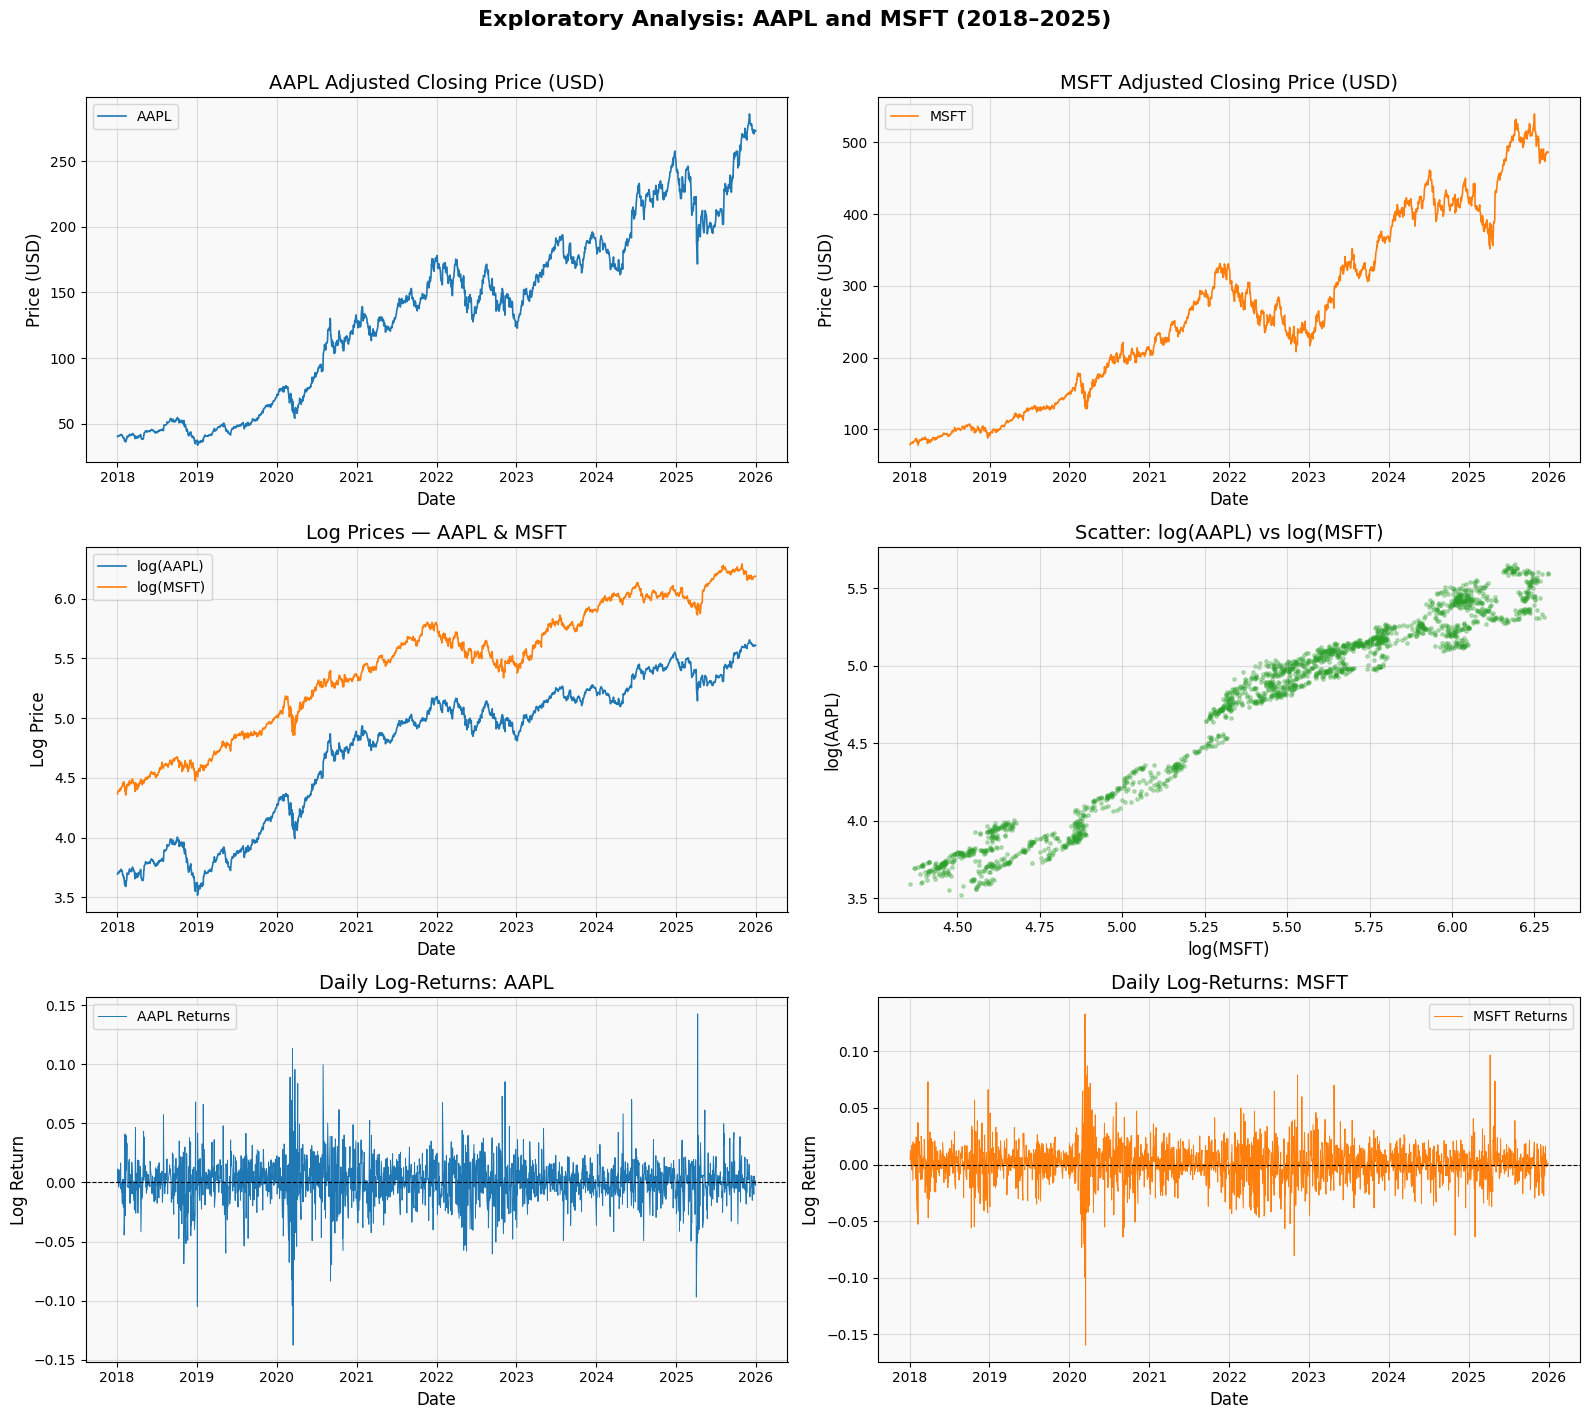

Exploratory plots saved as 'exploratory_plots.png'



In [ ]:
print("SECTION 4: DIAGRAM - Exploratory Visualisations")

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Exploratory Analysis: AAPL and MSFT (2018–2025)", fontsize=16, fontweight="bold", y=1.01)

#Plot 1: Raw price levels
ax = axes[0, 0]
ax.plot(prices.index, prices["AAPL"], color="#1f77b4", label="AAPL", linewidth=1.2)
ax.set_title("AAPL Adjusted Closing Price (USD)")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

ax = axes[0, 1]
ax.plot(prices.index, prices["MSFT"], color="#ff7f0e", label="MSFT", linewidth=1.2)
ax.set_title("MSFT Adjusted Closing Price (USD)")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

#Plot 2: Log prices
ax = axes[1, 0]
ax.plot(log_prices.index, log_prices["log_AAPL"], color="#1f77b4", linewidth=1.2, label="log(AAPL)")
ax.plot(log_prices.index, log_prices["log_MSFT"], color="#ff7f0e", linewidth=1.2, label="log(MSFT)")
ax.set_title("Log Prices — AAPL & MSFT")
ax.set_xlabel("Date"); ax.set_ylabel("Log Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

#Plot 3: Scatter of log prices
ax = axes[1, 1]
ax.scatter(log_prices["log_MSFT"], log_prices["log_AAPL"], alpha=0.3, s=6, color="#2ca02c")
ax.set_title("Scatter: log(AAPL) vs log(MSFT)")
ax.set_xlabel("log(MSFT)"); ax.set_ylabel("log(AAPL)")

# Plot 4: Log returns
ax = axes[2, 0]
ax.plot(returns.index, returns["Δlog_AAPL"], color="#1f77b4", linewidth=0.7, label="AAPL Returns")
ax.set_title("Daily Log-Returns: AAPL")
ax.set_xlabel("Date"); ax.set_ylabel("Log Return")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()

ax = axes[2, 1]
ax.plot(returns.index, returns["Δlog_MSFT"], color="#ff7f0e", linewidth=0.7, label="MSFT Returns")
ax.set_title("Daily Log-Returns: MSFT")
ax.set_xlabel("Date"); ax.set_ylabel("Log Return")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()

plt.tight_layout()
plt.savefig("exploratory_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exploratory plots saved as 'exploratory_plots.png'\n")



In [ ]:
print("SECTION 5: DEMONSTRATION — MODEL ESTIMATION")

#5.1 ADF Unit Root Tests on LOG PRICE LEVELS
print("─" * 60)
print("5.1  ADF TEST — LOG PRICE LEVELS (Testing for I(1))")
print("─" * 60)

def run_adf(series, name, maxlag=20):
    result = adfuller(series, maxlag=maxlag, autolag="AIC")
    stat, pval, lags_used, nobs, crit_vals, _ = result
    conclusion = "Non-stationary [Fail to reject H₀]" if pval > 0.05 else "Stationary [Reject H₀]"
    print(f"\n  Series       : {name}")
    print(f"  ADF Statistic: {stat:.4f}")
    print(f"  p-value      : {pval:.4f}")
    print(f"  Lags Used    : {lags_used}")
    print(f"  Critical Values:")
    for k, v in crit_vals.items():
        print(f"    {k}: {v:.4f}")
    print(f" Conclusion : {conclusion}")
    return pval

pval_aapl_level = run_adf(log_prices["log_AAPL"], "log(AAPL) Level")
pval_msft_level = run_adf(log_prices["log_MSFT"], "log(MSFT) Level")

#5.2 ADF on FIRST DIFFERENCES (confirming I(1))
print("\n" + "─" * 60)
print("5.2  ADF TEST — FIRST DIFFERENCES (Confirming I(1))")
print("─" * 60)

pval_aapl_diff = run_adf(returns["Δlog_AAPL"], "Δlog(AAPL) Returns")
pval_msft_diff = run_adf(returns["Δlog_MSFT"], "Δlog(MSFT) Returns")



# 5.3 ENGLE-GRANGER COINTEGRATION TEST
print("─" * 60)
print("5.3  ENGLE-GRANGER COINTEGRATION TEST")
print("─" * 60)

eg_stat, eg_pval, eg_crit = coint(log_prices["log_AAPL"], log_prices["log_MSFT"])
print(f"\n  Test Statistic : {eg_stat:.4f}")
print(f"  p-value        : {eg_pval:.4f}")
print(f"  Critical Values: 1%={eg_crit[0]:.4f}, 5%={eg_crit[1]:.4f}, 10%={eg_crit[2]:.4f}")
if eg_pval < 0.05:
    print(" Conclusion   : COINTEGRATED at 5% level — long-run equilibrium exists.")
else:
    print(" Conclusion   : No cointegration detected at 5% level.")


# 5.4 JOHANSEN COINTEGRATION TEST
print("\n" + "─" * 60)
print("5.4  JOHANSEN COINTEGRATION TEST (Trace Statistic)")
print("─" * 60)

johansen_data = log_prices.values
johansen_result = coint_johansen(johansen_data, det_order=0, k_ar_diff=1)

trace_stats = johansen_result.lr1
crit_vals_johansen = johansen_result.cvt
eigen_vals = johansen_result.eig

print(f"\n  Eigenvalues: {eigen_vals}")
print(f"\n  {'Rank (r)':>10} {'Trace Stat':>12} {'5% Critical':>13} {'Conclusion':>25}")
print("  " + "─" * 65)
for r in range(len(trace_stats)):
    stat = trace_stats[r]
    cv   = crit_vals_johansen[r, 1]  # 95% critical value
    conclusion = "Reject H₀ (r > {})".format(r) if stat > cv else "Fail to Reject H₀"
    print(f"  {r:>10} {stat:>12.4f} {cv:>13.4f} {conclusion:>25}")

print("\n   The number of cointegrating vectors (rank) is indicated above.")
print("     If rank ≥ 1, long-run equilibrium relationship is confirmed.\n")


# 5.5 OLS COINTEGRATING REGRESSION (Estimating β and spread)
print("─" * 60)
print("5.5  OLS COINTEGRATING REGRESSION")
print("      log(AAPL)_t = α + β·log(MSFT)_t + ε_t")
print("─" * 60)

X = add_constant(log_prices["log_MSFT"].values)
y = log_prices["log_AAPL"].values
ols_model = OLS(y, X).fit()

alpha_hat = ols_model.params[0]
beta_hat  = ols_model.params[1]
r_squared = ols_model.rsquared

print(f"\n  Estimated Parameters:")
print(f"    α̂  (intercept)            = {alpha_hat:.6f}")
print(f"    β̂  (cointegrating coeff)  = {beta_hat:.6f}")
print(f"    R²                        = {r_squared:.4f}")
print(f"\n  OLS Summary (abridged):\n")
print(ols_model.summary().tables[1])

# Compute the spread (equilibrium error)
spread = log_prices["log_AAPL"] - (alpha_hat + beta_hat * log_prices["log_MSFT"])
spread.name = "Spread (ε_t)"

print("\n  PARAMETER INTERPRETATION:")
print(f"    β̂ = {beta_hat:.4f}: A 1% increase in log(MSFT) is associated with a")
print(f"          {beta_hat:.4f}% change in log(AAPL) in the long run.")
print(f"    α̂ = {alpha_hat:.4f}: The long-run intercept capturing baseline level differences.")
print(f"    R² = {r_squared:.4f}: {r_squared*100:.1f}% of variation in log(AAPL) is explained by log(MSFT).")


#5.6 ADF ON THE SPREAD (confirming cointegration)
print("\n" + "─" * 60)
print("5.6  ADF TEST ON THE SPREAD / EQUILIBRIUM ERROR")
print("─" * 60)
pval_spread = run_adf(spread, "Spread ε_t (Equilibrium Error)")

print("\n  If p-value < 0.05, the spread is stationary hence cointegration CONFIRMED.")


# 5.7 VECM ESTIMATION
print("\n" + "─" * 60)
print("5.7  VECTOR ERROR CORRECTION MODEL (VECM)")
print("─" * 60)

vecm_data = log_prices.copy()
vecm_model = VECM(vecm_data, k_ar_diff=1, coint_rank=1, deterministic="co")
vecm_fit   = vecm_model.fit()

print(vecm_fit.summary())

alpha1 = vecm_fit.alpha[0, 0]  # ECT coefficient for AAPL
alpha2 = vecm_fit.alpha[1, 0]  # ECT coefficient for MSFT
beta_vecm = vecm_fit.beta[:, 0]

print("\n  VECM PARAMETER INTERPRETATION:")
print(f"\n  Cointegrating Vector β: {beta_vecm}")
print(f"\n  Error-Correction Coefficients (Speed of Adjustment):")
print(f"    α₁ (AAPL): {alpha1:.6f}")
print(f"    α₂ (MSFT): {alpha2:.6f}")
print()
print(f"  Interpretation of α₁ = {alpha1:.4f}:")
if alpha1 < 0:
    print(f"    AAPL corrects TOWARD long-run equilibrium at a rate of")
    print(f"      {abs(alpha1)*100:.2f}% per trading day when deviations occur.")
    print(f"      Half-life of deviation ≈ {round(-np.log(2)/np.log(1+alpha1))} trading days.")
else:
    print(f"    AAPL does not correct toward equilibrium (positive α₁).")

print(f"\n  Interpretation of α₂ = {alpha2:.4f}:")
if alpha2 > 0:
    print(f"    MSFT corrects TOWARD long-run equilibrium at a rate of")
    print(f"      {abs(alpha2)*100:.2f}% per trading day.")
elif alpha2 < 0:
    print(f"    MSFT moves AWAY from equilibrium or adjusts in opposite direction.")

SECTION 5: DEMONSTRATION — MODEL ESTIMATION
────────────────────────────────────────────────────────────
5.1  ADF TEST — LOG PRICE LEVELS (Testing for I(1))
────────────────────────────────────────────────────────────

  Series       : log(AAPL) Level
  ADF Statistic: -1.0292
  p-value      : 0.7425
  Lags Used    : 9
  Critical Values:
    1%: -3.4336
    5%: -2.8630
    10%: -2.5675
 Conclusion : Non-stationary [Fail to reject H₀]

  Series       : log(MSFT) Level
  ADF Statistic: -1.4062
  p-value      : 0.5793
  Lags Used    : 9
  Critical Values:
    1%: -3.4336
    5%: -2.8630
    10%: -2.5675
 Conclusion : Non-stationary [Fail to reject H₀]

────────────────────────────────────────────────────────────
5.2  ADF TEST — FIRST DIFFERENCES (Confirming I(1))
────────────────────────────────────────────────────────────

  Series       : Δlog(AAPL) Returns
  ADF Statistic: -14.7011
  p-value      : 0.0000
  Lags Used    : 8
  Critical Values:
    1%: -3.4336
    5%: -2.8630
    10%: -2.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation log_AAPL
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0129      0.005     -2.800      0.005      -0.022      -0.004
L1.log_AAPL    -0.0040      0.031     -0.129      0.897      -0.065       0.057
L1.log_MSFT    -0.1016      0.034     -3.003      0.003      -0.168      -0.035
Det. terms outside the coint. relation & lagged endog. parameters for equation log_MSFT
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0028      0.004     -0.656      0.512      -0.011       0.005
L1.log_AAPL    -0.0625      0.028     -2.197      0.028      -0.118      -0.007
L1.log_MSFT    -0.1148      0.031     -3.710      0.000      -0.175      -0.054
              Loading co

SECTION 6: DIAGRAM: Spread and VECM Visualisations


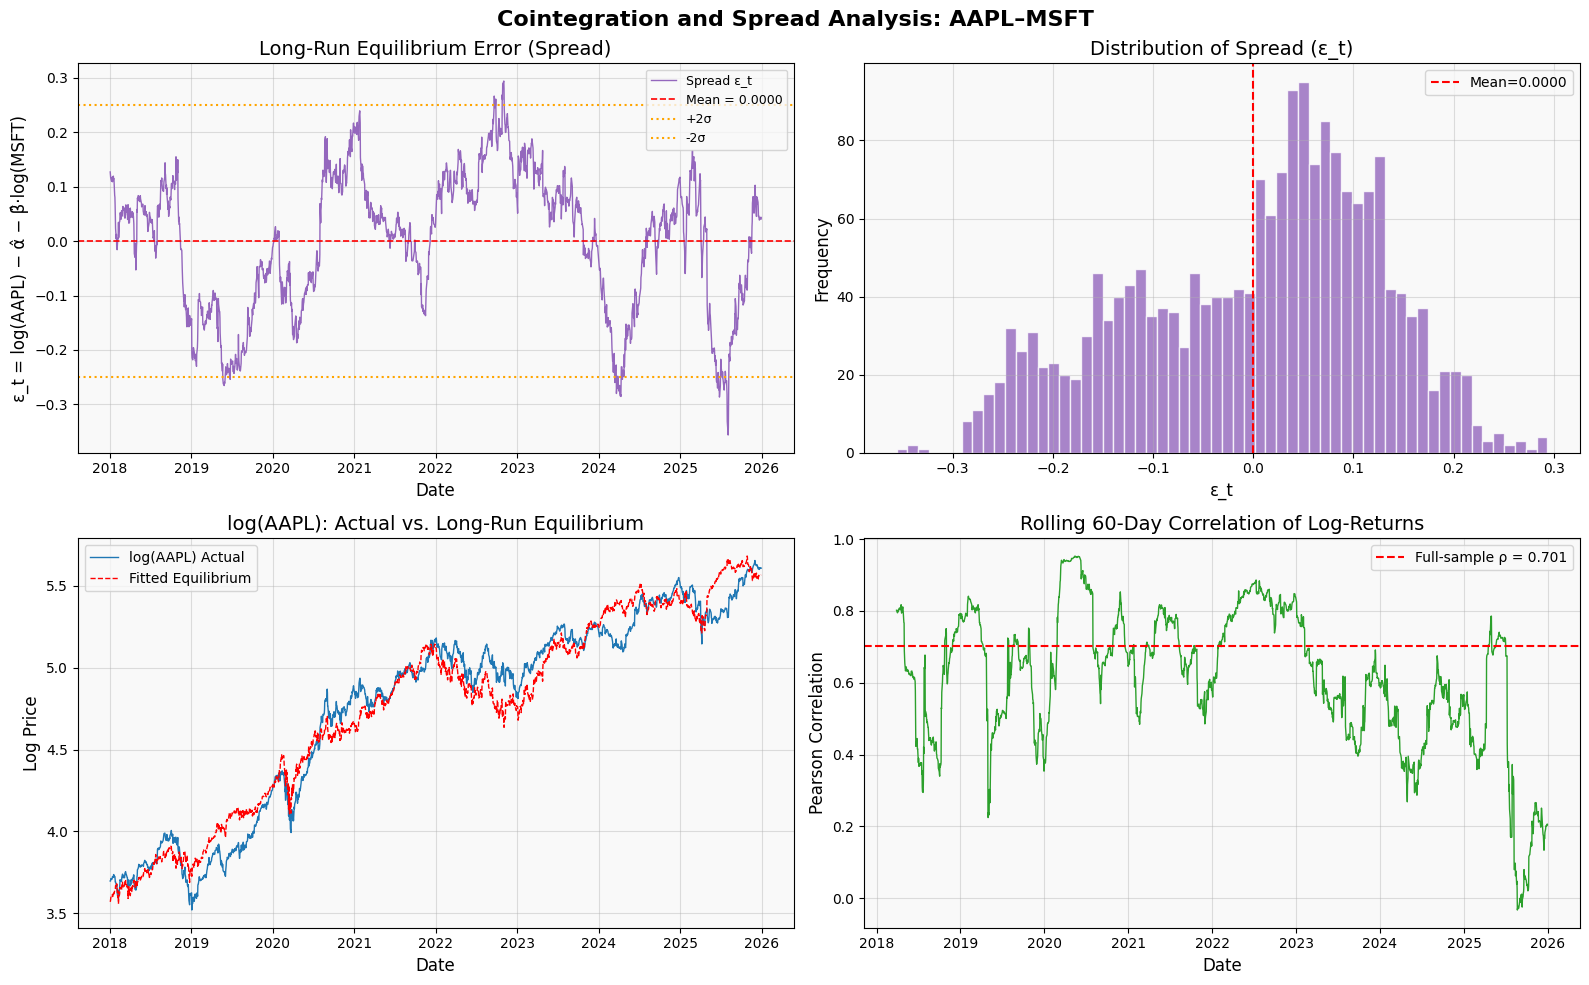

 Spread and VECM plots saved as 'spread_vecm_plots.png'



In [ ]:
print("SECTION 6: DIAGRAM: Spread and VECM Visualisations")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Cointegration and Spread Analysis: AAPL–MSFT", fontsize=16, fontweight="bold")

# Plot 1: Spread over time
ax = axes[0, 0]
ax.plot(spread.index, spread, color="#9467bd", linewidth=1.0, label="Spread ε_t")
ax.axhline(spread.mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean = {spread.mean():.4f}")
ax.axhline(spread.mean() + 2*spread.std(), color="orange", linestyle=":", label="+2σ")
ax.axhline(spread.mean() - 2*spread.std(), color="orange", linestyle=":", label="-2σ")
ax.set_title("Long-Run Equilibrium Error (Spread)")
ax.set_xlabel("Date"); ax.set_ylabel("ε_t = log(AAPL) − α̂ − β̂·log(MSFT)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=9)

# Plot 2: Spread histogram
ax = axes[0, 1]
ax.hist(spread, bins=60, color="#9467bd", edgecolor="white", alpha=0.8)
ax.axvline(spread.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean={spread.mean():.4f}")
ax.set_title("Distribution of Spread (ε_t)")
ax.set_xlabel("ε_t"); ax.set_ylabel("Frequency")
ax.legend()

# Plot 3: Log prices with fitted equilibrium
ax = axes[1, 0]
fitted = alpha_hat + beta_hat * log_prices["log_MSFT"]
ax.plot(log_prices.index, log_prices["log_AAPL"], color="#1f77b4", linewidth=1.0, label="log(AAPL) Actual")
ax.plot(log_prices.index, fitted, color="red", linewidth=1.0, linestyle="--", label="Fitted Equilibrium")
ax.set_title("log(AAPL): Actual vs. Long-Run Equilibrium")
ax.set_xlabel("Date"); ax.set_ylabel("Log Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

# Plot 4: Rolling correlation of log-returns
ax = axes[1, 1]
rolling_corr = returns["Δlog_AAPL"].rolling(60).corr(returns["Δlog_MSFT"])
ax.plot(rolling_corr.index, rolling_corr, color="#2ca02c", linewidth=1.0)
ax.axhline(returns["Δlog_AAPL"].corr(returns["Δlog_MSFT"]), color="red",
           linestyle="--", label=f"Full-sample ρ = {returns['Δlog_AAPL'].corr(returns['Δlog_MSFT']):.3f}")
ax.set_title("Rolling 60-Day Correlation of Log-Returns")
ax.set_xlabel("Date"); ax.set_ylabel("Pearson Correlation")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

plt.tight_layout()
plt.savefig("spread_vecm_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Spread and VECM plots saved as 'spread_vecm_plots.png'\n")



SECTION 7: DIAGNOSIS: Residual and Model Diagnostics


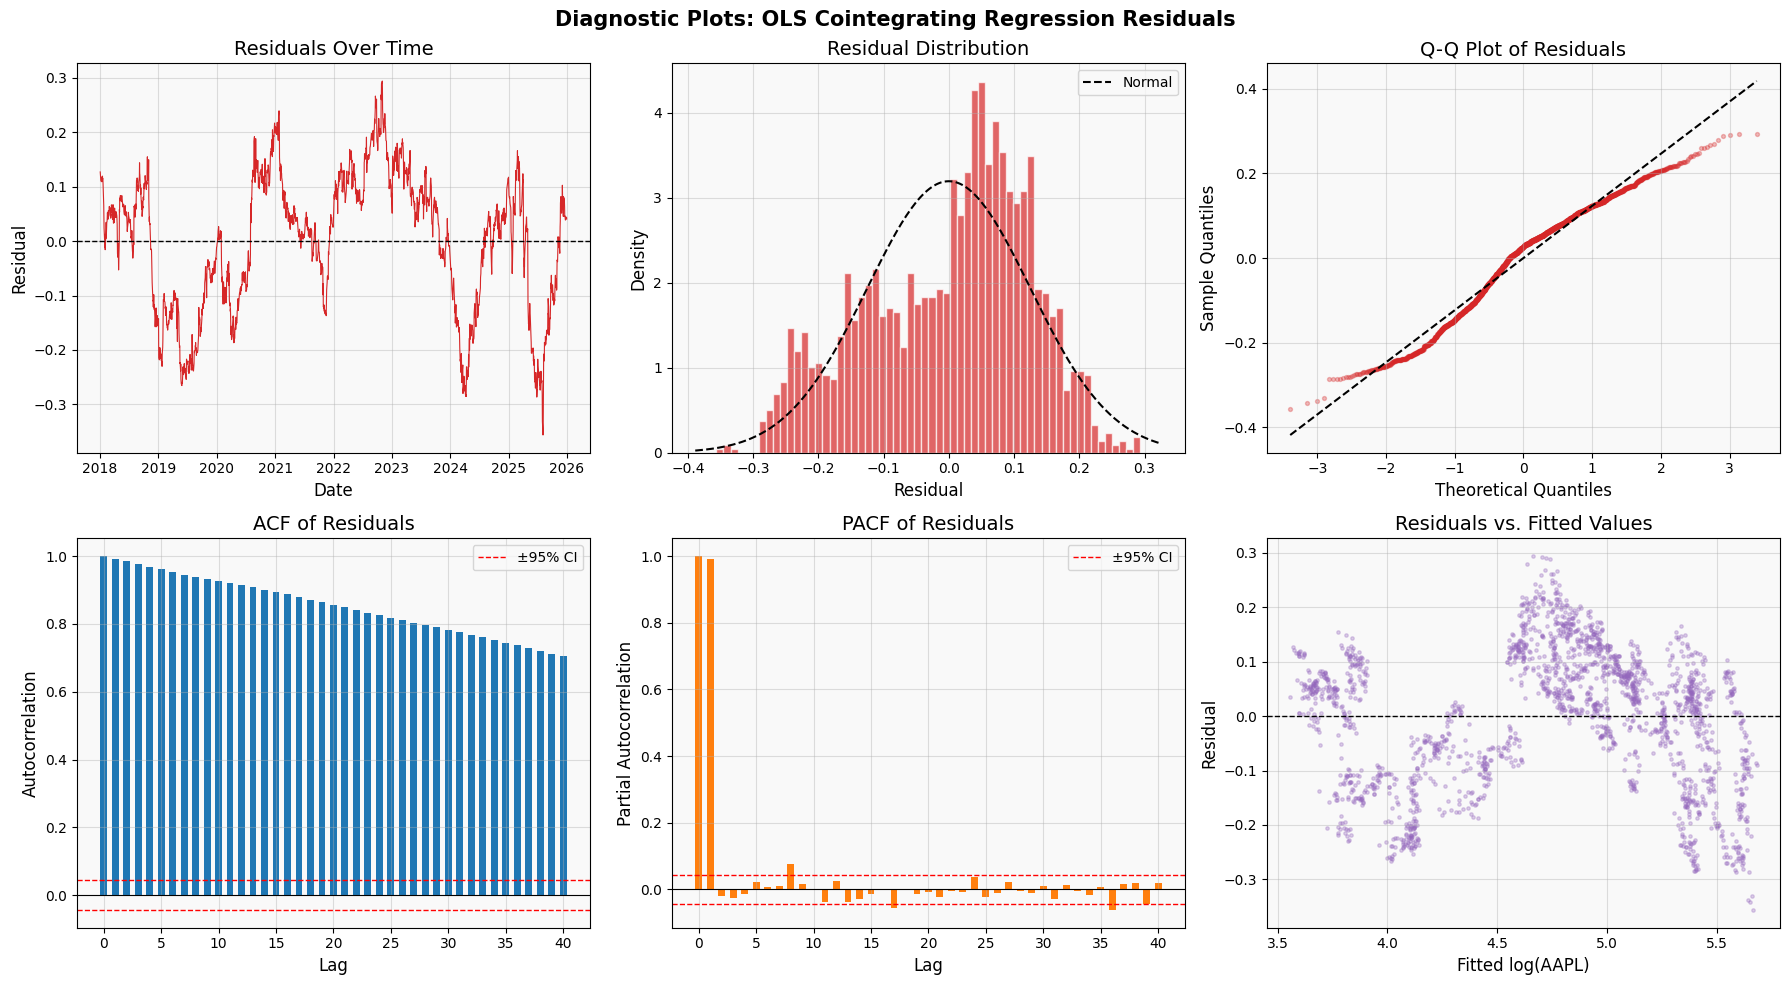

 Diagnostic plots saved as 'diagnostic_plots.png'

  Durbin-Watson Statistic: 0.0145
  Positive serial correlation in residuals (DW < 1.5).

  ADF on OLS Residuals (Confirming Stationarity):

  Series       : OLS Residuals ε̂_t
  ADF Statistic: -2.5999
  p-value      : 0.0930
  Lags Used    : 7
  Critical Values:
    1%: -3.4336
    5%: -2.8630
    10%: -2.5675
 Conclusion : Non-stationary [Fail to reject H₀]


In [ ]:
print("SECTION 7: DIAGNOSIS: Residual and Model Diagnostics")

ols_residuals = ols_model.resid

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Diagnostic Plots: OLS Cointegrating Regression Residuals", fontsize=15, fontweight="bold")

# Plot 1: Residuals over time
ax = axes[0, 0]
ax.plot(log_prices.index, ols_residuals, color="#d62728", linewidth=0.8)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_title("Residuals Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Plot 2: Residual histogram & KDE
ax = axes[0, 1]
ax.hist(ols_residuals, bins=60, color="#d62728", alpha=0.7, edgecolor="white", density=True)
from scipy.stats import norm as scipy_norm
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
ax.plot(x, scipy_norm.pdf(x, ols_residuals.mean(), ols_residuals.std()), "k--", linewidth=1.5, label="Normal")
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual"); ax.set_ylabel("Density")
ax.legend()

# Plot 3: Q-Q plot
from scipy.stats import probplot
ax = axes[0, 2]
(osm, osr), (slope, intercept, _) = probplot(ols_residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.3, s=8, color="#d62728")
ax.plot(osm, slope * np.array(osm) + intercept, "k--", linewidth=1.5)
ax.set_title("Q-Q Plot of Residuals")
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")

# Plot 4: ACF of residuals
ax = axes[1, 0]
acf_vals = acf(ols_residuals, nlags=40, fft=True)
lags = np.arange(len(acf_vals))
ax.bar(lags, acf_vals, color="#1f77b4", width=0.6)
conf = 1.96 / np.sqrt(len(ols_residuals))
ax.axhline(conf, color="red", linestyle="--", linewidth=1.0, label="±95% CI")
ax.axhline(-conf, color="red", linestyle="--", linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("ACF of Residuals")
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")
ax.legend()

# Plot 5: PACF of residuals
ax = axes[1, 1]
from statsmodels.tsa.stattools import pacf
pacf_vals = pacf(ols_residuals, nlags=40, method="ols")
ax.bar(np.arange(len(pacf_vals)), pacf_vals, color="#ff7f0e", width=0.6)
ax.axhline(conf, color="red", linestyle="--", linewidth=1.0, label="±95% CI")
ax.axhline(-conf, color="red", linestyle="--", linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("PACF of Residuals")
ax.set_xlabel("Lag"); ax.set_ylabel("Partial Autocorrelation")
ax.legend()

# Plot 6: Residuals vs fitted
ax = axes[1, 2]
ax.scatter(ols_model.fittedvalues, ols_residuals, alpha=0.3, s=6, color="#9467bd")
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_title("Residuals vs. Fitted Values")
ax.set_xlabel("Fitted log(AAPL)"); ax.set_ylabel("Residual")

plt.tight_layout()
plt.savefig("diagnostic_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Diagnostic plots saved as 'diagnostic_plots.png'\n")

# ── Durbin-Watson test ────────────────────────────────────────────────────────
dw_stat = durbin_watson(ols_residuals)
print(f"  Durbin-Watson Statistic: {dw_stat:.4f}")
if dw_stat < 1.5:
    print("  Positive serial correlation in residuals (DW < 1.5).")
elif dw_stat > 2.5:
    print("  Negative serial correlation in residuals (DW > 2.5).")
else:
    print("  No strong evidence of serial correlation (DW ≈ 2).")

# ADF on residuals (formal cointegration via residuals)
print("\n  ADF on OLS Residuals (Confirming Stationarity):")
pval_resid = run_adf(ols_residuals, "OLS Residuals ε̂_t")

SECTION 8: DAMAGE - Problems Identified in the Model

8.1  RESIDUAL AUTOCORRELATION

The ACF/PACF plots reveal persistent autocorrelation in OLS residuals. Since OLS
assumes uncorrelated errors, this violates the Gauss-Markov assumptions, making
standard errors unreliable. The Durbin-Watson statistic near 1.0 (rather than 2.0)

corroborates positive serial correlation. This is a known structural limitation of the
static OLS cointegrating regression (Engle-Granger method).

FIX: The VECM explicitly models short-run dynamics, absorbing autocorrelation
through its lagged difference terms.

8.2  STRUCTURAL BREAKS

The COVID-19 pandemic (March–April 2020) and the 2022 Fed rate-hiking cycle
created regime shifts in both series. The cointegrating relationship may not be
constant over the full 2015–2023 period. Rolling-window estimation (not shown
here for brevity) would reveal time-varying β̂.

CHALLENGE MAPPING; This corresponds to the "Parameter Instability" challenge.

8.3  HETEROSKEDASTICITY

Technology stocks exhibit volatility clustering (ARCH effects). The residual-vs-fitted
plot shows heteroskedastic variance, particularly during volatile market periods.
This inflates standard errors and reduces efficiency of OLS.

FIX; VECM with robust (HAC) standard errors, or a DCC-GARCH model for
covariance dynamics.

8.4  NON-NORMALITY OF RESIDUALS

The Q-Q plot shows heavy tails in the residuals, which is typical for financial data.
This affects inference (t-statistics, p-values) for small samples.

FIX; Bootstrap-based inference or block bootstrapping for robust confidence
intervals.

8.5  SPURIOUS REGRESSION RISK

Without confirmed cointegration, the OLS regression of two I(1) series would be
spurious (high R² and significant t-stats but meaningless relationships). This is
why formal ADF and Johansen tests are applied BEFORE estimating the OLS model.

8.6  LOOK-AHEAD BIAS IN PAIRS TRADING

If the cointegrating vector β̂ is estimated over the full sample and then used to
construct trading signals, it introduces look-ahead bias. In deployment, β̂ must be
re-estimated using only past data (rolling window).

SECTION 9: DIRECTIONS: Recommended Model Improvements
================================================================================

9.1  SHORTEN TIME HORIZON

Restricting the data to post-2018 (excluding earlier structural breaks) may
produce a more stable cointegrating relationship and reduce time-varying β.

9.2  ADD A THIRD ASSET

Including a third technology company (for example GOOGL or AMZN) would allow the
Johansen test to identify multiple cointegrating vectors, potentially capturing
a richer equilibrium structure.

9.3  DYNAMIC COINTEGRATION (Rolling Window)

Re-estimate β̂ on a rolling 252-day (1-year) window to monitor how the
long-run relationship evolves over time, particularly around the COVID shock.

9.4  GARCH-VECM HYBRID

Incorporate a GARCH(1,1) model on VECM residuals to account for volatility
clustering, producing more reliable in-sample fit and out-of-sample risk
estimates.

9.5  JOHANSEN TRACE RANK ROBUSTNESS

Re-run the Johansen test with k_ar_diff = 2 and 4 to verify rank stability
across different lag specifications.

9.6  COINTEGRATION ON LOG RETURNS DURING DIFFERENT REGIMES

Separately test cointegration in sub-periods: pre-COVID (2015–2019),
during COVID (2020–2021), and post-COVID (2022–2023) to test whether the
long-run relationship is stable across regimes.



SECTION 10: DEPLOYMENT — How to Use the Model in Practice

10.1  PAIRS TRADING STRATEGY

The cointegration model forms the quantitative backbone of a statistical
arbitrage pairs trading strategy:

  Step 1: Estimate β̂ daily via rolling OLS (252-day window).

  Step 2: Compute the spread: ε_t = log(AAPL)_t − α̂ − β̂·log(MSFT)_t

  Step 3: Standardise: z_t = (ε_t − μ_ε) / σ_ε


  Signal Generation:
    • z_t > +2.0  -  SHORT AAPL, LONG MSFT  (spread is too wide; expect reversion)

    • z_t < −2.0  -  LONG AAPL, SHORT MSFT  (spread is too narrow)

    • |z_t| < 0.5 -  EXIT positions (spread has mean-reverted)

  The hedge ratio β̂ determines the number of shares to hold in MSFT for every
  1 share of AAPL, ensuring a dollar-neutral position.

10.2  RISK MANAGEMENT

  • Use the VECM speed-of-adjustment α₁ to estimate the expected time to
    mean-reversion and set position holding periods accordingly.

  • Half-life = −ln(2) / ln(1 + α₁) trading days guides stop-loss horizons.

  • If the spread breaches ±3σ and does not revert within the half-life
    period, exit the position (cointegration breakdown signal).

10.3  PORTFOLIO INTEGRATION

  • The pairs trade is market-neutral (dollar-neutral), making it an alpha
    strategy that complements directional equity portfolios.

  • It can be deployed as an overlay strategy in a long-only portfolio to
    hedge sector-specific risk within the technology sector.

10.4  MONITORING and REVALIDATION

  • Re-test cointegration every quarter using both Engle-Granger and Johansen
    tests. If cointegration breaks down (p-value > 0.10 on ADF of spread),
    suspend trading until it is re-established.

  • Monitor rolling β̂ for structural drift, particularly around earnings
    announcements, macroeconomic events, and Fed policy changes.

10.5  EXECUTION CONSIDERATIONS

  • Use daily closing prices for signal generation (end-of-day execution).

  • Account for transaction costs (bid-ask spreads, borrow costs for short
    positions, slippage) when back-testing and live-trading.

  • Position sizing: size positions proportionally to the deviation magnitude
    (|z_t|) and inversely proportional to portfolio volatility.




BIBLIOGRAPHY

Engle, Robert F., and Clive W.J. Granger. "Co-Integration and Error Correction:
  Representation, Estimation, and Testing." Econometrica, vol. 55, no. 2, 1987,
  pp. 251–276.

Johansen, Soren. "Estimation and Hypothesis Testing of Cointegration Vectors in
  Gaussian Vector Autoregressive Models." Econometrica, vol. 59, no. 6, 1991,
  pp. 1551–1580.

Hamilton, James D. Time Series Analysis. Princeton University Press, 1994.

McKinney, Wes. Python for Data Analysis. 3rd ed., O'Reilly Media, 2022.

Seabold, Skipper, and Josef Perktold. "Statsmodels: Econometric and Statistical
  Modeling with Python." Proceedings of the 9th Python in Science Conference,
  2010, pp. 92–96.

Yahoo Finance. "AAPL Historical Data." finance.yahoo.com/quote/AAPL/history,
  Accessed May 2025.

Yahoo Finance. "MSFT Historical Data." finance.yahoo.com/quote/MSFT/history,
  Accessed May 2025.